In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
import os

import warnings

from Crime_Data_Preprocessing_Pipeline import preprocess, table_structure, data_split, data_cleaning, feature_engineering
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# BRONZE LAYER
_________________________________________________________________________________________________________
### LOAD (TO BRONZE LAYER)
Connect to the API and fetch the data and save it to the bronze layer


In [2]:
## Connect to the API and fetch the data
# 1. Load variables from the .env file into the system environment
load_dotenv()

# 2. Access variables using os.getenv()
my_secret = os.getenv("EASYDATA_API_KEY")
EASYDATA_API_URL = "https://www.easydata.co.za/api/v3/"

In [3]:
from quantec.easydata.client import Client
# All parameters and defaults
client = Client(
    api_key= my_secret,  # default: uses EASYDATA_API_KEY env var
    api_url=EASYDATA_API_URL,  # default: EASYDATA_API_URL or "https://www.easydata.co.za/api/v3"
    use_cache=True,
    cache_dir="cache",
)

In [30]:
# Extract my data using the selection_pk and frequency parameters (M = Monthly)
df1 = client.get_data(selection_pk = 19053, freq = "A")
df2 = client.get_data(selection_pk = 19058, freq = "A")
df3 = client.get_data(selection_pk = 19059, freq = "A")

In [39]:
population_density = client.get_data(selection_pk = 19268, freq = "A")
poor_households = client.get_data(selection_pk = 19269, freq = "A")
population_unemployment = client.get_data(selection_pk = 19265, freq = "A")


In [40]:
pop_edu_1 = client.get_data(selection_pk = 19270, freq = "A")
pop_edu_2 = client.get_data(selection_pk = 19271, freq = "A")
pop_edu_3 = client.get_data(selection_pk = 19272, freq = "A")
pop_edu_4 = client.get_data(selection_pk = 19273, freq = "A")
pop_edu_5 = client.get_data(selection_pk = 19274, freq = "A")
pop_edu_6 = client.get_data(selection_pk = 19275, freq = "A")

In [36]:
# Load the data to the Bronze Layer
df1.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Crime Data/1st Batch.xlsx", index=False)
df2.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Crime Data/2nd Batch.xlsx", index=False)
df3.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Crime Data/3rd Batch.xlsx", index=False)


In [45]:
population_density.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Features/population_density.xlsx", index=False)
poor_households.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Features/poor_households.xlsx", index=False)
pop_edu_1.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Features/population_education_1.xlsx", index=False)
pop_edu_2.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Features/population_education_2.xlsx", index=False)
pop_edu_3.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Features/population_education_3.xlsx", index=False)
pop_edu_4.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Features/population_education_4.xlsx", index=False)
pop_edu_5.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Features/population_education_5.xlsx", index=False)
pop_edu_6.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Features/population_education_6.xlsx", index=False)
population_unemployment.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Features/population_unemployment.xlsx", index=False)

### EXTRACT (FROM BRONZE LAYER)
Extract the data from the bronze layer and load it into a dataframe for transformation

In [2]:
df1 = pd.read_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Crime Data/1st Batch.xlsx")
df2 = pd.read_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Crime Data/2nd Batch.xlsx")
df3 = pd.read_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/1. Bronze Layer/Crime Data/3rd Batch.xlsx")

# SILVER LAYER
## TRANSFORM
Transform the data by applying the necessary transformations such as data cleaning, feature engineering, and data splitting. This can be done using pipelines to ensure that the transformations are applied consistently and efficiently.

In [3]:
# The pipelines take in a list of dataframes as input and apply the transformations to each dataframe in the list. The output is a single dataframe that has been transformed and is ready for loading into the silver layer.
X = [df1, df2, df3]

In [4]:
preprocess_pipe = Pipeline([
    ("Preprocessor", preprocess())
    ])
table_str_pipe = Pipeline([
    ("Table Structure", table_structure())
    ])

In [5]:
data = preprocess_pipe.fit_transform(X)
data = table_str_pipe.fit_transform(X)

In [6]:
data_split_pipe = Pipeline([
    ("Split Data", data_split()),
    ("Clean Data", data_cleaning()),
    ("New Cols", feature_engineering())
    ])
crime_data = data_split_pipe.fit_transform(data)

In [7]:
crime_data = crime_data.sort_values(by=["Cluster", "date"])

### LOAD TO SILVER LAYER

In [8]:
crime_data.to_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/2. Silver Layer/Crime Data/cleaned_crime_data.xlsx", index=False)

In [10]:
df = pd.read_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/2. Silver Layer/Crime Data/cleaned_crime_data.xlsx")
df

,date,Year,Month,Day,Province,Cluster,Type of Crime,value
0,1995-12-31,1995,December,Sunday,Limpopo,Bela Bela Cluster,Serious and Other crimes,4967
1,1995-12-31,1995,December,Sunday,Limpopo,Bela Bela Cluster,Serious crimes,4719
2,1995-12-31,1995,December,Sunday,Limpopo,Bela Bela Cluster,Community reported Serious crimes,4469
3,1995-12-31,1995,December,Sunday,Limpopo,Bela Bela Cluster,Contact crimes (Crimes against the person),1555
4,1995-12-31,1995,December,Sunday,Limpopo,Bela Bela Cluster,Murder,30
...,...,...,...,...,...,...,...,...
19075,2024-12-31,2024,December,Tuesday,Limpopo,Tzaneen Cluster,Culpable homicide,100
19076,2024-12-31,2024,December,Tuesday,Limpopo,Tzaneen Cluster,Public violence,3
19077,2024-12-31,2024,December,Tuesday,Limpopo,Tzaneen Cluster,Crimen injuria,157
19078,2024-12-31,2024,December,Tuesday,Limpopo,Tzaneen Cluster,Neglect and ill-treatment of children,24


In [15]:
print(df.value.mean(), "\n")
print(df.value.var())

778.5988993710691 

4201903.916734467


<Axes: xlabel='value', ylabel='Count'>

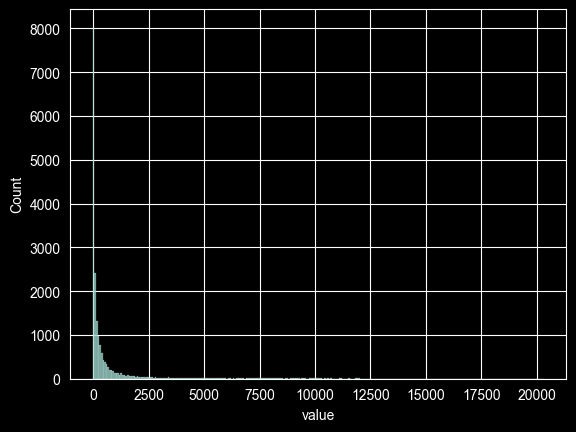

In [17]:
sns.histplot(df, x = "value")

This is a Poisson Distribution, which is a discrete probability distribution that expresses the probability of a given number of events occurring in a fixed interval of time or space, given a known average rate of occurrence. The variance of a Poisson distribution is larger and the data is overly dispersed, which is consistent with the values we calculated for the "value" column in our dataset. The histogram also shows that the data is skewed to the right, which is typical for count data that follows a Poisson distribution. We will model this using a Poisson Regression model, which is a type of generalized linear model that is used to model count data and contingency tables. It assumes that the response variable has a Poisson distribution and that the logarithm of its expected value can be modeled by a linear combination of unknown parameters.

### PLAN
Read other datasets and consolidate them
1. Explore Data Distributions and do feature selection
2. Train and Test Split
3. Encode the features
4. Normalize the values
5. Select and Train Model
6. Evaluate Model
7. Tune Parameters
8. Evaluate Model
9. Insights

In [96]:
demographics_df = pd.read_excel(r"C:/Users/amare/OneDrive/Desktop/Crime Hotspots Capstone Project/datasets/Data Lakehouse/2. Silver Layer/Features/Features.xlsx")

In [105]:
crime_data.rename(columns = {"value": "Crime Count"}, inplace=True)

In [106]:
crime_data.drop(columns = ["Year", "Month", "Day" , "Province"], inplace=True)

In [107]:
crime_data.Cluster = crime_data.Cluster.str.strip()

In [108]:
crime_data.Cluster.unique()

array(['Bela Bela Cluster', 'Burgersfort Cluster', 'Giyani Cluster',
       'Groblersdal Cluster (inc. Laersdrift post-Mar-18)',
       'Lephalale Cluster',
       'Mahwelereng Cluster (inc. part of Moletlane pre-May-21)',
       'Makhado Cluster', 'Mankweng Cluster', 'Modimolle Cluster',
       'Seshego Cluster', 'Thohoyandou Cluster', 'Tzaneen Cluster'],
      dtype=object)

In [58]:
demographics_df.Cluster.unique()

array(['Bela-Bela', 'Elias Motsoaledi', 'Fetakgomo-Greater Tubatse',
       'Greater Giyani', 'Greater Tzaneen', 'Lephalale',
       'Limpopo — Unemployed', 'Makhado', 'Modimolle-Mookgophong',
       'Mogalakwena', 'Polokwane', 'Thulamela'], dtype=object)

In [110]:
crime_data["Cluster"] = crime_data["Cluster"].replace({
    "Bela Bela Cluster": "Bela Bela",
    'Burgersfort Cluster' : "Burgersfort",
    'Giyani Cluster' : "Giyani",
    'Lephalale Cluster' : "Lephalale",
    'Groblersdal Cluster (inc. Laersdrift post-Mar-18)': "Groblersdal",
    'Mokopane Cluster' : "Mokopane",
    'Mahwelereng Cluster (inc. part of Moletlane pre-May-21)': "Mahwelereng",
    'Makhado Cluster': "Makhado",
    'Mankweng Cluster': "Polokwane",
    'Modimolle Cluster': "Modimolle",
    'Seshego Cluster': "Polokwane",
    'Thohoyandou Cluster': "Thohoyandou",
    'Tzaneen Cluster': "Tzaneen"

})

In [111]:
demographics_df["Cluster"] = demographics_df["Cluster"].replace({
    'Bela-Bela' : "Bela Bela",
    'Fetakgomo-Greater Tubatse' : "Burgersfort",
    'Elias Motsoaledi' : "Groblersdal",
    'Greater Giyani' : "Giyani",
    'Greater Tzaneen': "Tzaneen",
    'Limpopo — Unemployed': np.nan,
    'Modimolle-Mookgophong': "Modimolle",
    'Mogalakwena': "Mahwelereng",
    'Polokwane': "Polokwane",
    'Thulamela': "Thohoyandou"
}).dropna()

In [112]:
crime_data["Cluster"].unique()

array(['Bela Bela', 'Burgersfort', 'Giyani', 'Groblersdal', 'Lephalale',
       'Mahwelereng', 'Makhado', 'Polokwane', 'Modimolle', 'Thohoyandou',
       'Tzaneen'], dtype=object)

In [118]:
demographics_df.sort_values(by=["Cluster", "date"], inplace=True)
crime_data.sort_values(by=["Cluster", "date"], inplace=True)

In [123]:
full_df = crime_data.merge(demographics_df, on = ["Cluster", "date"], how = "outer").dropna()
full_df

,date,Day,Cluster,Type of Crime,Crime Count,population_density,population_education,population_unemployment,poor_households
0,1995-12-31,Sunday,Bela Bela,Serious and Other crimes,4967.0,50832.0,4094.0,2598,1281.0
1,1995-12-31,Sunday,Bela Bela,Serious and Other crimes,4967.0,50832.0,4094.0,2598,1281.0
2,1995-12-31,Sunday,Bela Bela,Serious and Other crimes,4967.0,50832.0,4094.0,2598,1281.0
3,1995-12-31,Sunday,Bela Bela,Serious and Other crimes,4967.0,50832.0,4094.0,2598,1281.0
4,1995-12-31,Sunday,Bela Bela,Serious and Other crimes,4967.0,50832.0,4180.0,2598,1281.0
...,...,...,...,...,...,...,...,...,...
7326715,2024-12-31,Tuesday,Tzaneen,Kidnapping,54.0,429298.0,24.0,51659,11851.0
7326716,2024-12-31,Tuesday,Tzaneen,Kidnapping,54.0,429298.0,25.0,51659,11851.0
7326717,2024-12-31,Tuesday,Tzaneen,Kidnapping,54.0,429298.0,25.0,51659,11851.0
7326718,2024-12-31,Tuesday,Tzaneen,Kidnapping,54.0,429298.0,25.0,51659,11851.0
